In [17]:
import torch
import numpy as np
import os
import sys
import pickle as pk
import tqdm
from glob import glob
from torch.utils.data import Dataset, DataLoader
module_path = os.path.abspath('..')
if module_path not in sys.path:
    sys.path.append(module_path)
    
from utils import ini_argparse, split_dataset

In [44]:
import matplotlib.pyplot as plt
from utils.plot import configure_matplotlib_fabio

configure_matplotlib_fabio(theme='light', figsize=(6,4))

In [19]:
import pickle as pk
import numpy as np
import torch
import os
import sys
from glob import glob
from torch.utils.data import Dataset
from utils import ini_argparse
from utils.augmentations import *
import MinkowskiEngine as ME


class SparseFASERCALDataset(Dataset):
    def __init__(self, args):
        """
        Initializes the SparseFASERCALDataset class.

        Args:
        root (str): Root directory containing the data files.
        shuffle (bool): Whether to shuffle the dataset (default: False).
        """
        self.root = args.dataset_path
        self.data_files = self.processed_file_names
        self.load_seg = args.load_seg
        self.stage1 = args.stage1
        self.train = args.train
        self.augmentations_enabled = False
        self.is_v5 = True if 'v5' in args.dataset_path else False 
        self.total_events = self.__len__
        
        self.plot_distributions = False

        with open(self.root + "/metadata.pkl", "rb") as fd:
            self.metadata = pk.load(fd)
            self.metadata['x'] = np.array(self.metadata['x'])
            self.metadata['y'] = np.array(self.metadata['y'])
            self.metadata['z'] = np.array(self.metadata['z'])

            
    @property
    def processed_dir(self):
        """
        Returns the processed directory path.

        Returns:
        str: Path to the processed directory.
        """
        return f'{self.root}'
    
    
    @property
    def processed_file_names(self):
        """
        Returns a list of processed file names.

        Returns:
        list: List of file names.
        """
        return glob(f'{self.processed_dir}/*.npz')
    
    
    def __len__(self):
        """
        Returns the total number of data files.

        Returns:
        int: Number of data files.
        """
        return len(self.data_files)

    def voxelise(self, coords, reverse=False):
        """
        Voxelises or unvoxelises given coordinates.
        
        Note: Voxelisation different for Z since module positions are not uniform.
        """
        min_x, max_x = self.metadata['x'].min(), self.metadata['x'].max()
        min_y, max_y = self.metadata['y'].min(), self.metadata['y'].max()
        range_x = self.metadata['x'].shape[0] - 1
        range_y = self.metadata['y'].shape[0] - 1

        def forward_transform(values, min_val, max_val, range_max):
            return range_max * (values - min_val) / (max_val - min_val)

        def inverse_transform(values, min_val, max_val, range_max):
            return min_val + (values / range_max) * (max_val - min_val)

        transform = inverse_transform if reverse else forward_transform

        mapped = np.empty_like(coords, dtype=np.float32)
        mapped[..., 0] = transform(coords[..., 0], min_x, max_x, range_x)
        mapped[..., 1] = transform(coords[..., 1], min_y, max_y, range_y)
        if reverse:
            mapped[..., 2] = self.metadata['z'][coords[..., 2].astype(int), 0]
        else:
            mapped[..., 2] = np.searchsorted(self.metadata['z'][:, 0], coords[..., 2])

        return mapped.round()  # round needed only for augmentations
    
    
    def normalise_seg_labels(self, seg_labels, eps=1e-8):
        """
        Normalise seg_labels by:
        - Keeping the first column unchanged as it represents ghost identification.
        - Normalizing the second and third columns (energy depositions from electromagnetic and hadronic components) so that their sum equals (1 - first column value) per row.
        """
        
        sum_values = np.sum(seg_labels[:, 1:], axis=1, keepdims=True)
        mask = sum_values.squeeze() > 0
        seg_labels[mask, 1:] = (1 - seg_labels[mask, 0:1]) * (seg_labels[mask, 1:] / sum_values[mask, :])
    
        return seg_labels

        
    def pdg2label(self, pdg, iscc, name=False):
        """
        PDG to label.
        """
        if iscc:
            if pdg in [-12, 12]:
                label = "CC nue" if name else 0
            elif pdg in [-14, 14]:
                label = "CC numu" if name else 1
            elif pdg in [-16, 16]:
                label = "CC nutau" if name else 2
        else:
            label = "NC" if name else 3

        return label
    
    
    def decompose_momentum(self, momentum):
        """
        Given a 3D momentum vector or an array of N 3D momentum vectors, 
        return the magnitudes and directions separately.
        
        Parameters:
            momentum (np.ndarray): A (3,) or (N, 3) NumPy array representing momentum vector(s).
            
        Returns:
            magnitude (np.ndarray): The magnitude(s) of the momentum vector(s).
            direction (np.ndarray): A unit vector (or unit vectors) representing the direction(s) of the momentum.
        """
        momentum = np.atleast_2d(momentum)  # Converts (3,) -> (1, 3), leaves (N,3) unchanged
        magnitudes = np.linalg.norm(momentum, axis=1, keepdims=True)
        directions = np.divide(momentum, magnitudes, where=magnitudes != 0)
    
        if magnitudes.shape[0] == 1:
            return magnitudes[0], directions[0]
    
        return magnitudes.flatten(), directions

    
    def reconstruct_momentum(self, magnitude, direction):
        """
        Given magnitude and direction, reconstruct the original momentum vector.
        
        Parameters:
            magnitude (float or np.ndarray): A scalar or an array of shape (N,) representing momentum magnitudes.
            direction (np.ndarray): A (3,) or (N, 3) NumPy array representing unit direction vectors.
            
        Returns:
            momentum (np.ndarray): The reconstructed momentum vector(s).
        """
        magnitude = np.atleast_1d(magnitude)
        direction = np.atleast_2d(direction)  # Converts (3,) -> (1, 3), leaves (N,3) unchanged
    
        momentum = magnitude[:, np.newaxis] * direction
    
        return momentum[0] if magnitude.shape[0] == 1 else momentum

    
    def standardize(self, x, param_name):
        return (x - self.metadata[param_name]['mean']) / self.metadata[param_name]['std']    
    
    
    def divide_by_std(self, x, param_name):
        return x / self.metadata[param_name]['std']
    
    
    def get_param(self, data, param_name, preprocess=False):
        if param_name not in data:
            return None

        param = data[param_name]
        if param.ndim == 0:
            param = param.reshape(1,) if preprocess else param.item()
        param = self.divide_by_std(param, param_name) if preprocess else param
        
        return param

    
    def __getitem__(self, idx):
        """
        Retrieves a data sample by index.

        Args:
        idx (int): Index of the data sample.

        Returns:
        dict: Data sample with filename, coordinates, features, and labels.
        """
        data = np.load(self.data_files[idx], allow_pickle=True)
        
        run_number = self.get_param(data, 'run_number')
        event_id = self.get_param(data, 'event_id')
        true_hits = self.get_param(data, 'true_hits')
        reco_hits = self.get_param(data, 'reco_hits')
        reco_hits_true = self.get_param(data, 'reco_hits_true')
        in_neutrino_pdg = self.get_param(data, 'in_neutrino_pdg')
        in_neutrino_energy = self.get_param(data, 'in_neutrino_energy')
        out_lepton_pdg = self.get_param(data, 'out_lepton_pdg')
        out_lepton_momentum = self.get_param(data, 'out_lepton_momentum', preprocess=False)
        vis_sp_momentum = self.get_param(data, 'vis_sp_momentum', preprocess=False)
        jet_momentum = self.get_param(data, 'jet_momentum', preprocess=False)
        is_cc = self.get_param(data, 'is_cc')
        e_vis = self.get_param(data, 'e_vis', preprocess=True)
        pt_miss = self.get_param(data, 'pt_miss', preprocess=False)
        rear_cal_energy = self.get_param(data, 'pt_miss', preprocess=True)
        rear_hcal_energy = self.get_param(data, 'rear_hcal_energy', preprocess=True)
        rear_mucal_energy = self.get_param(data, 'rear_mucal_energy', preprocess=True)
        faser_cal_energy = self.get_param(data, 'faser_cal_energy', preprocess=True)
        rear_hcal_modules = self.get_param(data, 'rear_hcal_modules', preprocess=True)
        faser_cal_modules = self.get_param(data, 'faser_cal_modules', preprocess=True)
        primary_vertex = data['primary_vertex']
        
        if not self.is_v5 and not is_cc:
            # Fix jet momentum and no outgoing lepton momentum for NC events
            jet_momentum = jet_momentum + out_lepton_momentum
            out_lepton_momentum.fill(0)
        
        # momentum -> direction + magnitude
        out_lepton_momentum_mag, out_lepton_momentum_dir = self.decompose_momentum(out_lepton_momentum)
        out_lepton_momentum_mag = self.divide_by_std(out_lepton_momentum_mag, 'out_lepton_momentum_magnitude')
        jet_momentum_mag, jet_momentum_dir = self.decompose_momentum(jet_momentum)
        jet_momentum_mag = self.divide_by_std(jet_momentum_mag, 'jet_momentum_magnitude')
        
        # retrieve coordiantes and features (energy deposited)
        coords = reco_hits[:, :3]
        q = self.divide_by_std(reco_hits[:, 4].reshape(-1, 1), 'q')
        
        # process labels
        primlepton_labels = self.get_param(data, 'primlepton_labels')
        seg_labels = self.get_param(data, 'seg_labels')
        if self.load_seg:
            # load labels from pretrained model predictions
            file_name = self.data_files[idx].replace("events_v3.5", "events_v3.5_seg_results")
            predictions = np.load(file_name)
            primlepton_labels_pred, seg_labels_pred = predictions['out_primlepton'], predictions['out_seg']
            
            # convert electromagnetic and hadronic probabilities to energy desposits (using truth info)
            seg_labels_pred[:, 1:] *= (seg_labels[:, 1:].sum(axis=1, keepdims=True) + 1e-8)            
            
            # predictions become labels
            primlepton_labels = primlepton_labels_pred
            seg_labels = seg_labels_pred
        
        # voxelise coordinates and prepare global features and labels
        coords = self.voxelise(coords)
        primary_vertex = self.voxelise(primary_vertex)
        feats_global = np.concatenate([rear_cal_energy, rear_hcal_energy, rear_mucal_energy, 
                                       faser_cal_energy, rear_hcal_modules, faser_cal_modules])   
        
        flavour_label = self.pdg2label(in_neutrino_pdg, is_cc)
        primlepton_labels = primlepton_labels.reshape(-1,1)
        seg_labels = seg_labels.reshape(-1, 3)

        if self.is_v5:
            # mask out voxels between modules
            mask = ~(coords[:, 2] % 24 >= 20)
            coords = coords[mask]
            q = q[mask]
            primlepton_labels = primlepton_labels[mask]
            seg_labels = seg_labels[mask]

        augmented, feats = False, q
        if self.augmentations_enabled and np.random.rand() > 0.01:           
            # augmented event
            (
                coords, feats, (primlepton_labels, seg_labels),
                (out_lepton_momentum_dir, jet_momentum_dir, vis_sp_momentum)
            ) = self._augment(
                coords, feats, (primlepton_labels, seg_labels),
                (out_lepton_momentum_dir, jet_momentum_dir, vis_sp_momentum),
                primary_vertex
            )
            
            augmented = True
        else:
            seg_labels = self.normalise_seg_labels(seg_labels)
          
        if augmented:
            # merge duplicated coordinates and finalise with augmentations
            # coords, feats, primlepton_labels, seg_labels = self.aggregate_duplicate_coords(coords, feats, primlepton_labels, seg_labels)
            seg_labels = self.normalise_seg_labels(seg_labels)
            if not self.stage1 and not self.plot_distributions:
                primlepton_labels = add_gaussian_noise(primlepton_labels, shuffle_prob=0.)
                seg_labels = add_gaussian_noise(seg_labels, shuffle_prob=0.)
            feats_global = add_noise_global_params(feats_global)
        
        # ptmiss
        pt_miss = np.sqrt(np.array([vis_sp_momentum[0]**2 + vis_sp_momentum[1]**2]))
        pt_miss = self.divide_by_std(pt_miss, 'pt_miss')

        # output
        output = {}
        if not self.train:
            output['run_number'] = run_number
            output['event_id'] = event_id
            output['primary_vertex'] = primary_vertex
            output['is_cc'] = is_cc
            output['in_neutrino_pdg'] = in_neutrino_pdg
            output['in_neutrino_energy'] = in_neutrino_energy
            output['out_lepton_momentum_dir'] = torch.from_numpy(out_lepton_momentum_dir).float()
        if self.stage1:
            output['primlepton_labels'] = torch.from_numpy(primlepton_labels).float()
            output['seg_labels'] = torch.from_numpy(seg_labels).float()
        else:
            feats = np.concatenate((feats, primlepton_labels, seg_labels), axis=1)
            output['flavour_label'] = torch.tensor([flavour_label]).long()
            output['e_vis'] = torch.from_numpy(e_vis).float()
            output['pt_miss'] = torch.from_numpy(pt_miss).float()
            output['out_lepton_momentum_mag'] = torch.from_numpy(out_lepton_momentum_mag).float()
            output['out_lepton_momentum_dir'] = torch.from_numpy(out_lepton_momentum_dir).float()
            output['jet_momentum_mag'] = torch.from_numpy(jet_momentum_mag).float()
            output['jet_momentum_dir'] = torch.from_numpy(jet_momentum_dir).float()
        output['coords'] = torch.from_numpy(coords.reshape(-1, 3)).float()
        output['feats'] = torch.from_numpy(feats).float()
        output['feats_global'] = torch.from_numpy(feats_global).float()

        return feats_global, e_vis, pt_miss, flavour_label

In [20]:
# manually specify the GPUs to use
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#device = torch.device('cpu')

parser = ini_argparse()
args = parser.parse_args([])
args.dataset_path = "/scratch/salonso/sparse-nns/faser/events_v3.5"
args.batch_size = 32
args.num_workers = 32

print("\n- Arguments:")
for arg, value in vars(args).items():
    print(f"  {arg}: {value}")
nb_gpus = len(args.gpus)
gpus = [int(gpu) for gpu in args.gpus]


- Arguments:
  train: True
  stage1: True
  augmentations_enabled: True
  dataset_path: /scratch/salonso/sparse-nns/faser/events_v3.5
  sets_path: None
  load_seg: False
  eps: 1e-12
  batch_size: 32
  epochs: 50
  num_workers: 32
  lr: 0.0001
  accum_grad_batches: 1
  warmup_steps: 0
  cosine_annealing_steps: 0
  weight_decay: 0.05
  beta1: 0.9
  beta2: 0.999
  losses: ['focal', 'dice']
  save_dir: /scratch/salonso/sparse-nns/faser/deep_learning/faserDL
  name: v1
  log_every_n_steps: 50
  early_stop_patience: 0
  save_top_k: 1
  checkpoint_path: /scratch/salonso/sparse-nns/faser/deep_learning/faserDL/checkpoints
  checkpoint_name: v1
  load_checkpoint: None
  gpus: [0]


In [21]:
#improt dataloader
from torch.utils.data import DataLoader
dataset = SparseFASERCALDataset(args)
print("- Dataset size: {} events".format(len(dataset)))

def collate_fn(batch):
    feats_global = np.stack([x[0] for x in batch])
    evis = np.concatenate([x[1] for x in batch])
    ptmiss = np.concatenate([x[2] for x in batch])
    flavour = np.array([x[3] for x in batch])
    return feats_global, evis, ptmiss, flavour

loader = DataLoader(dataset, batch_size=50, num_workers=50, pin_memory=True, persistent_workers=True, collate_fn=collate_fn)

#train_loader, valid_loader, test_loader = split_dataset(dataset, args, splits=[0.6, 0.1, 0.3], test=True)

- Dataset size: 144939 events


In [22]:
from tqdm import tqdm
import numpy as np  # Ensure numpy is imported

feats_global_all = []
evis_all = []
ptmiss_all = []
flavour_all = []

for batch in tqdm(loader, total=len(loader), disable=False):
    feats_global_all.append(batch[0])
    evis_all.append(batch[1])
    ptmiss_all.append(batch[2])
    flavour_all.append(batch[3])

# Concatenate collected batches
feats_global_all = np.concatenate(feats_global_all)
evis_all = np.concatenate(evis_all)
ptmiss_all = np.concatenate(ptmiss_all)
flavour_all = np.concatenate(flavour_all)

100%|██████████| 2899/2899 [03:17<00:00, 14.64it/s]


# Predicitons 

## Flavour ALL

### E Vis

In [58]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = feats_global_all
y = np.stack((evis_all, flavour_all)).T

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = y_train[:, 0]
y_flavour = y_test[:, 1]
y_test = y_test[:, 0]

# Initialize XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror', 
    n_estimators=100,  
    learning_rate=0.1, 
    max_depth=5,
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb_reg.fit(X_train, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


RMSE: 0.5349


In [59]:
y_pred = y_pred*dataset.metadata["e_vis"]["std"] + dataset.metadata["e_vis"]["mean"]
y_test = y_test*dataset.metadata["e_vis"]["std"] + dataset.metadata["e_vis"]["mean"]

nue
mean 3.404959302942907
std 324.6828928460849


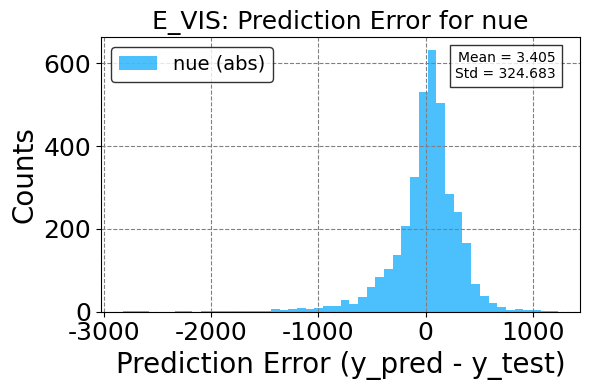

mean 0.03331395983666393
std 0.19412784105334455


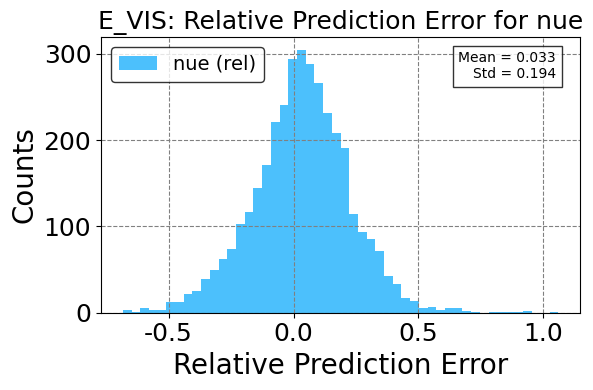

numu
mean -22.31224689512877
std 371.24625135815614


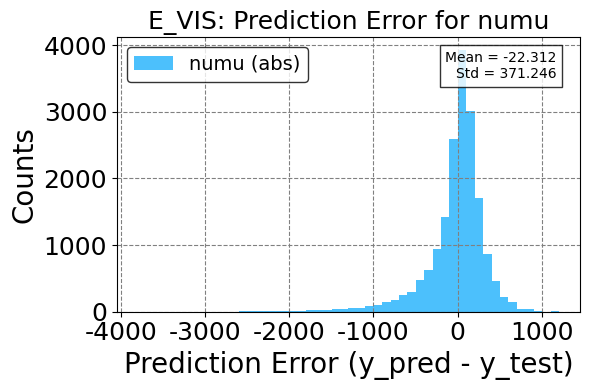

mean 0.03904882471736753
std 0.21565007867893604


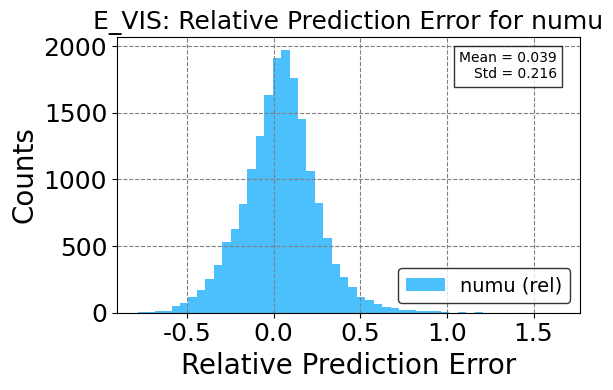

NC
mean 45.04633678896492
std 231.44615701986388


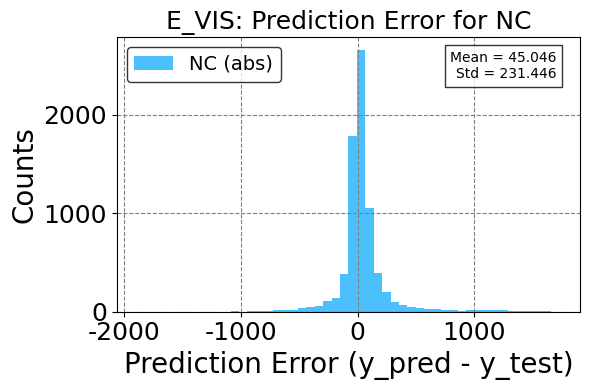

mean 0.05701476467213415
std 0.22196203465398504


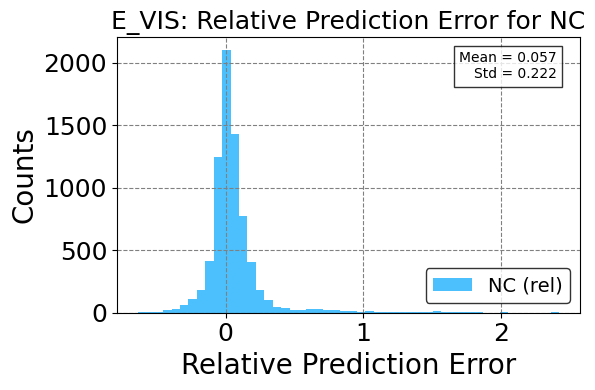

In [60]:
import matplotlib.pyplot as plt

flavour_labels = ['nue', 'numu', 'nutau', 'NC']
for i in range(4):
    if i == 2:
        continue
    print(flavour_labels[i])

    mask = y_flavour == i
    diff = y_pred[mask] - y_test[mask]

    mean_abs = diff.mean()
    std_abs = diff.std()

    print("mean", mean_abs)
    print("std", std_abs)
    
    plt.hist(diff, bins=50, label=f'{flavour_labels[i]} (abs)', alpha=0.7)
    plt.xlabel('Prediction Error (y_pred - y_test)')
    plt.ylabel('Counts')
    plt.title(f'E_VIS: Prediction Error for {flavour_labels[i]}')
    plt.legend()
    plt.grid(True)

    # Show mean and std on the plot
    textstr = f"Mean = {mean_abs:.3f}\nStd = {std_abs:.3f}"
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8))

    plt.show()
    
    rel = diff / y_test[mask]

    mean_rel = rel.mean()
    std_rel = rel.std()

    print("mean", mean_rel)
    print("std", std_rel)
    
    plt.hist(rel, bins=50, label=f'{flavour_labels[i]} (rel)', alpha=0.7)
    plt.xlabel('Relative Prediction Error')
    plt.ylabel('Counts')
    plt.title(f'E_VIS: Relative Prediction Error for {flavour_labels[i]}')
    plt.legend()
    plt.grid(True)

    # Show mean and std on the plot
    textstr = f"Mean = {mean_rel:.3f}\nStd = {std_rel:.3f}"
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8))

    plt.show()



### Pt Miss 

In [61]:
#!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X = feats_global_all
y = np.stack((ptmiss_all, flavour_all)).T

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = y_train[:, 0]
y_flavour = y_test[:, 1]
y_test = y_test[:, 0]

# Initialize XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=5,
    subsample=0.8, 
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb_reg.fit(X_train, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


RMSE: 0.0684


In [62]:
y_pred = y_pred*dataset.metadata["pt_miss"]["std"] + dataset.metadata["pt_miss"]["mean"]
y_test = y_test*dataset.metadata["pt_miss"]["std"] + dataset.metadata["pt_miss"]["mean"]

nue
mean (abs) -0.00263242766864275
std (abs) 0.05251557432769986


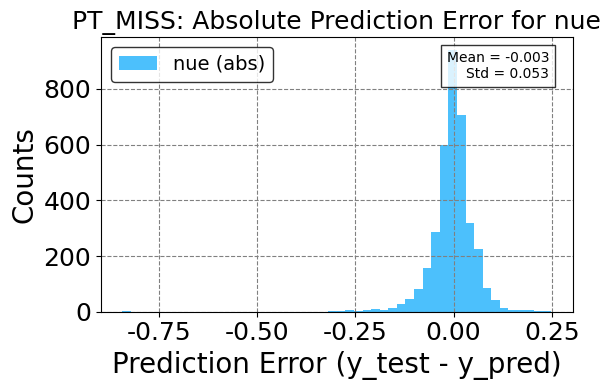

mean (rel) -0.001344501521841266
std (rel) 0.02888057517419592


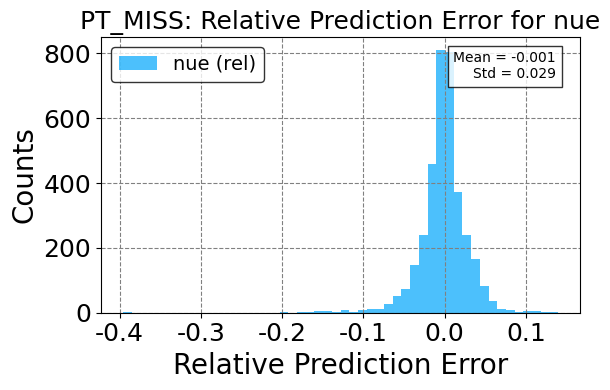

numu
mean (abs) -0.0015781793610006262
std (abs) 0.026173893972154715


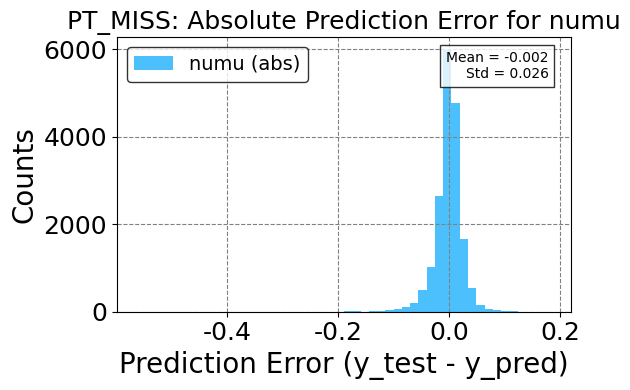

mean (rel) -0.0011091216594131634
std (rel) 0.01401705687672315


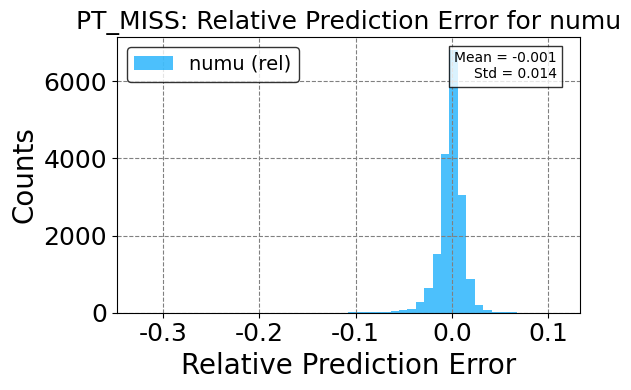

NC
mean (abs) 0.0045304490170022405
std (abs) 0.39390619019822365


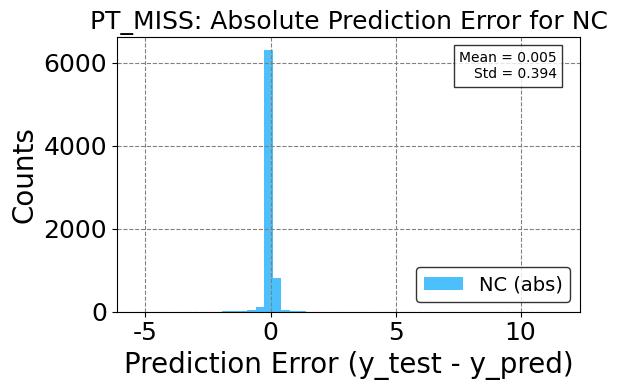

mean (rel) -0.0005946604509633353
std (rel) 0.020315998935075255


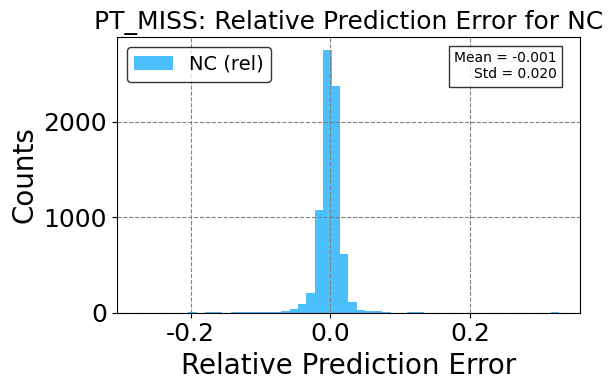

In [63]:
import matplotlib.pyplot as plt

flavour_labels = ['nue', 'numu', 'nutau', 'NC']
for i in range(4):
    if i == 2:
        continue  # Skip 'nutau' flavour
    
    print(flavour_labels[i])

    mask = y_flavour == i
    diff = y_test[mask] - y_pred[mask]

    # Absolute error statistics
    mean_abs = diff.mean()
    std_abs = diff.std()

    print("mean (abs)", mean_abs)
    print("std (abs)", std_abs)

    # Absolute prediction error plot
    plt.hist(diff, bins=50, label=f'{flavour_labels[i]} (abs)', alpha=0.7)
    plt.xlabel('Prediction Error (y_test - y_pred)')
    plt.ylabel('Counts')
    plt.title(f'PT_MISS: Absolute Prediction Error for {flavour_labels[i]}')
    plt.legend()
    plt.grid(True)

    # Add mean and std text
    textstr = f"Mean = {mean_abs:.3f}\nStd = {std_abs:.3f}"
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8))

    plt.show()

    # Relative error calculation
    rel = diff / y_test[mask]

    mean_rel = rel.mean()
    std_rel = rel.std()

    print("mean (rel)", mean_rel)
    print("std (rel)", std_rel)

    # Relative prediction error plot
    plt.hist(rel, bins=50, label=f'{flavour_labels[i]} (rel)', alpha=0.7)
    plt.xlabel('Relative Prediction Error')
    plt.ylabel('Counts')
    plt.title(f'PT_MISS: Relative Prediction Error for {flavour_labels[i]}')
    plt.legend()
    plt.grid(True)

    # Add mean and std text
    textstr = f"Mean = {mean_rel:.3f}\nStd = {std_rel:.3f}"
    plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
             fontsize=10, verticalalignment='top', horizontalalignment='right',
             bbox=dict(facecolor='white', alpha=0.8))

    plt.show()


## CC events Only

### E_vis

In [64]:
#!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

mask = flavour_all < 3
X = feats_global_all[mask]
y = np.stack((evis_all[mask], flavour_all[mask])).T

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = y_train[:, 0]
y_flavour = y_test[:, 1]
y_test = y_test[:, 0]

# Initialize XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb_reg.fit(X_train, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


RMSE: 0.5567


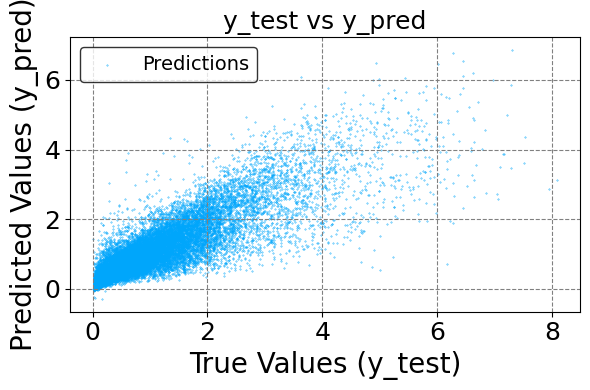

mean -0.001745534563291446
std 0.5566582416871426


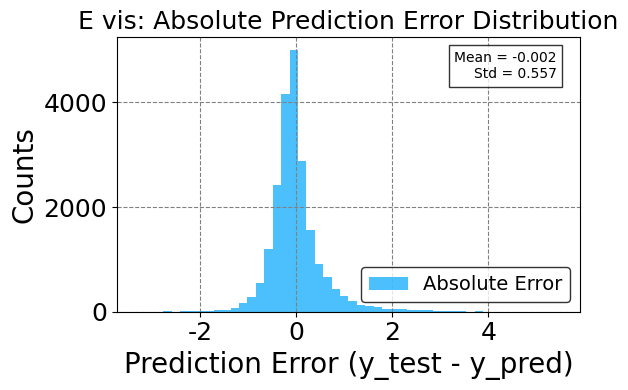

mean -0.3559947818811405
std 1.2930342457871153


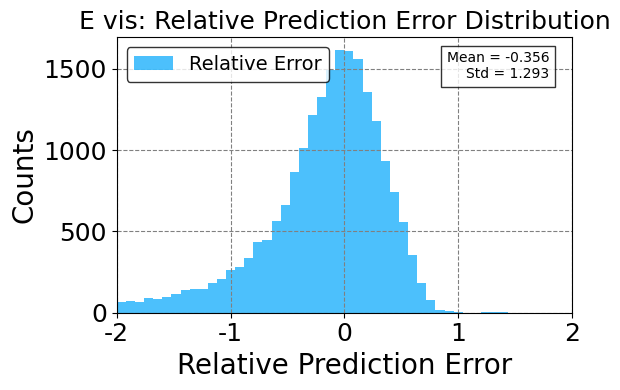

In [65]:
import matplotlib.pyplot as plt

diff = y_test - y_pred

# Scatter plot of predictions vs ground truth
plt.scatter(y_test, y_pred, s=0.1, label='Predictions')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('y_test vs y_pred')
plt.legend()
plt.grid(True)
plt.show()

# Absolute difference
mean_abs = diff.mean()
std_abs = diff.std()

print("mean", mean_abs)
print("std", std_abs)

plt.hist(diff, bins=50, alpha=0.7, label='Absolute Error')
plt.xlabel('Prediction Error (y_test - y_pred)')
plt.ylabel('Counts')
plt.title('E vis: Absolute Prediction Error Distribution')
plt.legend()
plt.grid(True)

# Annotate mean and std
textstr = f"Mean = {mean_abs:.3f}\nStd = {std_abs:.3f}"
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Relative difference
rel = diff / y_test

mean_rel = rel.mean()
std_rel = rel.std()

print("mean", mean_rel)
print("std", std_rel)

plt.hist(rel, bins=50, range=(-2, 2), alpha=0.7, label='Relative Error')
plt.xlabel('Relative Prediction Error')
plt.ylabel('Counts')
plt.title('E vis: Relative Prediction Error Distribution')
plt.xlim(-2, 2)
plt.legend()
plt.grid(True)

# Annotate mean and std
textstr = f"Mean = {mean_rel:.3f}\nStd = {std_rel:.3f}"
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()


## NC events only

###  PT miss

In [66]:
#!pip install xgboost
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

mask = flavour_all == 3
X = feats_global_all[mask]
y = np.stack((ptmiss_all[mask], flavour_all[mask])).T

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_train = y_train[:, 0]
y_flavour = y_test[:, 1]
y_test = y_test[:, 0]

# Initialize XGBoost regressor
xgb_reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Train the model
xgb_reg.fit(X_train, y_train)

# Make predictions
y_pred = xgb_reg.predict(X_test)

# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse:.4f}")


RMSE: 0.0518


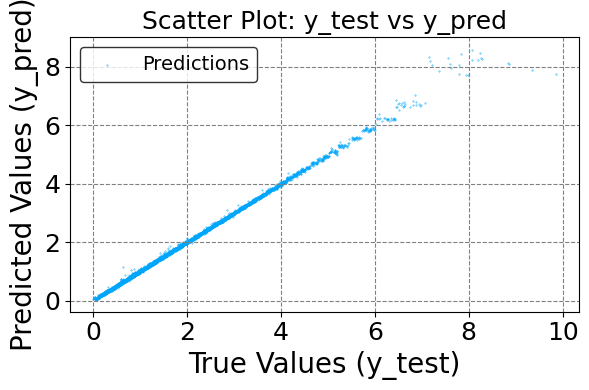

mean -0.0008833507870636807
std 0.05180183807874464


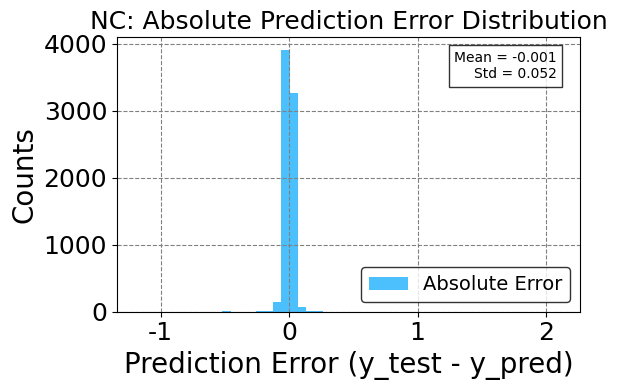

mean -0.006108725733333045
std 0.09773997411342177


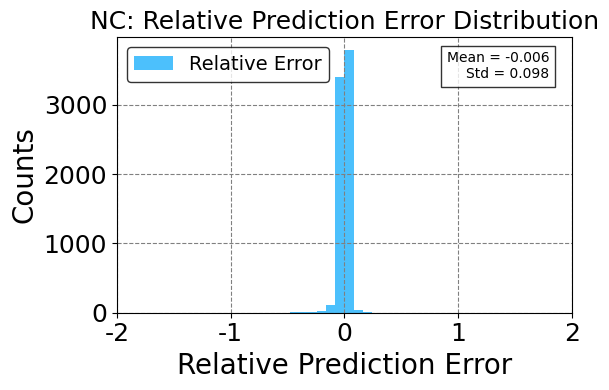

In [67]:
import matplotlib.pyplot as plt

diff = y_test - y_pred

# Scatter plot
plt.scatter(y_test, y_pred, s=0.1, label='Predictions')
plt.xlabel('True Values (y_test)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Scatter Plot: y_test vs y_pred')
plt.legend()
plt.grid(True)
plt.show()

# Absolute error histogram
mean_abs = diff.mean()
std_abs = diff.std()

print("mean", mean_abs)
print("std", std_abs)

plt.hist(diff, bins=50, alpha=0.7, label='Absolute Error')
plt.xlabel('Prediction Error (y_test - y_pred)')
plt.ylabel('Counts')
plt.title('NC: Absolute Prediction Error Distribution')
plt.legend()
plt.grid(True)

# Annotate mean and std
textstr = f"Mean = {mean_abs:.3f}\nStd = {std_abs:.3f}"
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

# Relative error histogram
rel = diff / y_test

mean_rel = rel.mean()
std_rel = rel.std()

print("mean", mean_rel)
print("std", std_rel)

plt.hist(rel, bins=50, range=(-2, 2), alpha=0.7, label='Relative Error')
plt.xlabel('Relative Prediction Error')
plt.ylabel('Counts')
plt.title('NC: Relative Prediction Error Distribution')
plt.xlim(-2, 2)
plt.legend()
plt.grid(True)

# Annotate mean and std
textstr = f"Mean = {mean_rel:.3f}\nStd = {std_rel:.3f}"
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes,
         fontsize=10, verticalalignment='top', horizontalalignment='right',
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()
